In [1]:
import qutip as qt
from qutip import *
import matplotlib.pyplot as plt
import numpy as np

## general solution for g(t)

In [2]:
from mpmath import *
def gamma_t(time, const, plot=0, form=0):
    center = (time[0] + time[-1]) / 2
    def Li_2(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(2, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_3(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(3, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_4(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(4, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_5(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(5, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_6(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(6, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    if form==0:
        top = (const/2)/(np.cosh(const*(time-center)))**2
        bottom = 1-(1/2)*(np.tanh(const*(time-center))-np.tanh(const*(time[0]-center)))
    elif form==1:                                                      
        top = (6*const**3/np.pi**2)*(time-center)**2/(np.cosh(const*(time-center)))**2
        def f(t):
            return 6 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) / np.pi**2
        bottom = 1-(f(const*(time-center))-f(const*(time[0]-center)))
    elif form==2:                                                    
        top = (45*const**5/2/np.pi**4) * ((time-center)**2 - (np.pi/const)**2/12)**2/ (np.cosh(const * (time - center)))**2
        def f(t):
            f_2 = 6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1)
            f_1 = -np.pi**2 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) /6
            f_0 = np.pi**4*np.tanh(t)/144
            return 45*(f_2 + f_1 + f_0)/2/np.pi**4
        bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))
    elif form==3:
        top = (350*const**7/9/np.pi**6) * ((time-center)**3 - 7*(np.pi/const)**2/20*(time-center))**2/ (np.cosh(const * (time - center)))**2
        def f(t):
            f_3 = 15*t**4*Li_2(t) + 30*t**3*Li_3(t) + 45*t**2*Li_4(t) + 45*t*Li_5(t) + 45/2*Li_6(t) - t**6*(1 - np.tanh(t)) - 6*t**5*np.log(np.exp(-2 * t) + 1)
            f_2 = -7*np.pi**2*(6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1))/10
            f_1 =  (7*np.pi**2/20)**2* (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t)))
            return 350*(f_3 + f_2 + f_1)/9/np.pi**6
        bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))
    if plot:
        plt.figure(figsize=(6,2))
        plt.plot(time, top/bottom/2/np.pi)
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.show()
    return top/bottom/2/np.pi

In [3]:
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from scipy.special import gamma, zeta, eval_hermite, factorial

# Define parameters
kappa = 2.5e-3*2*np.pi*2

# Define sech function
def sech(x):
    return 1 / np.cosh(x)

_kappa_cache = {}

def _N_m(m, kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

def _compute_Z_m(m, A_coeffs, kappa):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = _N_m(Nj_index, kappa)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1 / Z

def _get_A_m(m, kappa):
    if kappa not in _kappa_cache:
        _kappa_cache[kappa] = {
            "A_list": {0: [1.0]},
            "Z_dict": {0: kappa / 4},
        }

    A_list = _kappa_cache[kappa]["A_list"]
    Z_dict = _kappa_cache[kappa]["Z_dict"]

    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = _get_A_m(lower_m, kappa)

        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = _N_m(m - (i + j), kappa)
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = _compute_Z_m(m, A_m_coeffs, kappa)
    Z_dict[m] = Z_m
    A_list[m] = A_m_coeffs
    return A_m_coeffs

def xi_m(t, m, kappa):
    A_coeffs = _get_A_m(m, kappa)
    Zm = _kappa_cache[kappa]["Z_dict"][m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

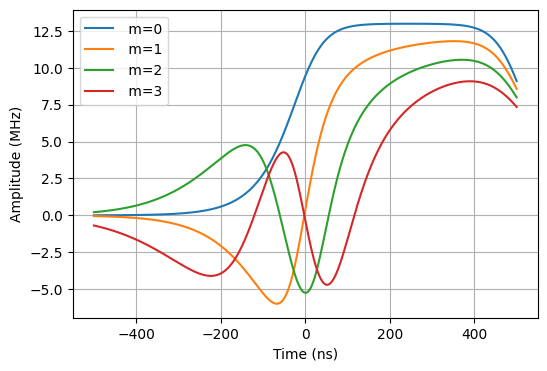

In [4]:

def f(t, m, kappa):
    return xi_m(t, m, kappa)

def f_prime(t, m, kappa, h=1e-3):
    return (f(t + h, m, kappa) - f(t - h, m, kappa)) / (2 * h)

def compute_g(t_vals, m, kappa, kappa_ph):
    f_vals = f(t_vals, m, kappa_ph)
    f_prime_vals = f_prime(t_vals, m, kappa_ph)
    

    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, t_vals, initial=0)
    
    numerator = f_prime_vals + (kappa * f_vals / 2)
    denominator = np.sqrt(kappa * (1 - integral_vals) - f2_vals)
    
    return numerator / denominator

kappa =  0.14*2*np.pi
kappa_ph = 2.5e-3*2*np.pi*2
t_vals = np.linspace(-500, 500, 501)

plt.figure(figsize=(6, 4))
for m in range(4):
    g_vals = compute_g(t_vals, m, kappa, kappa_ph)
    plt.plot(t_vals, np.real(g_vals)/2/np.pi*1e3, label=fr" m={m}")

plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (MHz)")
plt.legend()
plt.grid(True)
plt.show()


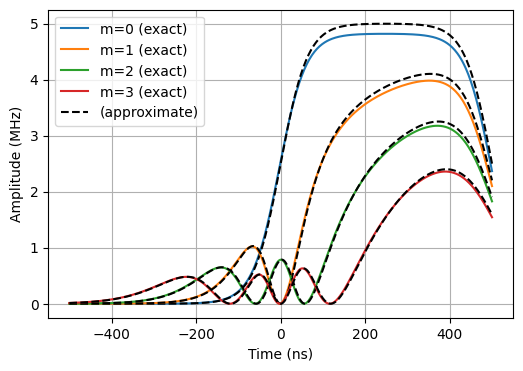

In [5]:
plt.figure(figsize=(6, 4))
for m in range(4):
    # print(t_vals, m, kappa, kappa_ph)
    g_vals = compute_g(t_vals, m, kappa, kappa_ph)
    plt.plot(t_vals, 4*g_vals**2/kappa/2/np.pi*1e3, label=fr"m={m} (exact)")
    Gamma_ana = gamma_t(t_vals, kappa_ph / 2, form=m)
    if m == 3:
        plt.plot(t_vals, Gamma_ana*1e3, linestyle='--', color="black", label="(approximate)")
    else:
        plt.plot(t_vals, Gamma_ana*1e3, linestyle='--', color="black")


plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (MHz)")
plt.legend()
plt.grid(True)
plt.show()

## QuTiP simulation

In [6]:
from process_tomography import *
from state_tomography import *
from libys import qtp as ysq
from datataking import search_datadict_miyamura
from qutip import fidelity, Qobj

In [7]:
n_cutoff_A = 3
n_cutoff_B = 3
n_cutoff_rA = 2
n_cutoff_rB = 2

b_A = qt.tensor(qt.destroy(n_cutoff_A), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
b_B = qt.tensor(qt.qeye(n_cutoff_A), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.destroy(n_cutoff_B))
a_A = qt.tensor(qt.qeye(n_cutoff_A), qt.destroy(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
a_B = qt.tensor(qt.qeye(n_cutoff_A), qt.qeye(n_cutoff_rA), qt.destroy(n_cutoff_rB), qt.qeye(n_cutoff_B))

zeromatrixxtmp=np.zeros([n_cutoff_A, n_cutoff_A])
zeromatrixxtmp[0,1]=1
gedecayop=Qobj(zeromatrixxtmp)
etog_A = qt.tensor(gedecayop, qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
etog_B = qt.tensor(qt.qeye(n_cutoff_B), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), gedecayop)
zeromatrixxtmp=np.zeros([n_cutoff_A, n_cutoff_A])
zeromatrixxtmp[1,2]=1
efdecayop=Qobj(zeromatrixxtmp)
ftoe_A = qt.tensor(efdecayop, qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
ftoe_B = qt.tensor(qt.qeye(n_cutoff_B), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), efdecayop)
zeromatrixxtmp=np.zeros([n_cutoff_A, n_cutoff_A])
zeromatrixxtmp[0,0]=-1
zeromatrixxtmp[1,1]=1
gedechoop=Qobj(zeromatrixxtmp)
dechoge_A = qt.tensor(gedechoop, qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
dechoge_B = qt.tensor(qt.qeye(n_cutoff_B), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), gedechoop)
zeromatrixxtmp=np.zeros([n_cutoff_A, n_cutoff_A])
zeromatrixxtmp[1,1]=-1
zeromatrixxtmp[2,2]=1
efdechoop=Qobj(zeromatrixxtmp)
dechoef_A = qt.tensor(efdechoop, qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
dechoef_B = qt.tensor(qt.qeye(n_cutoff_B), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), efdechoop)

g0_A = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
g0_B = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
f0_A = qt.tensor(qt.basis(n_cutoff_A, 2), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
g1_A = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 1), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
f0_B = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 2))
g1_B = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 1), qt.basis(n_cutoff_B, 0))
e0_A = qt.tensor(qt.basis(n_cutoff_A, 1), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
e0_B = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 1))

alpha_A = -0.356 * 2 * np.pi
chi_A = -0.0076 * 2 * np.pi
alpha_B = -0.356 * 2 * np.pi
chi_B = -0.004 * 2 * np.pi
eta = 0.67
kappa_A = 0.14 * 2 * np.pi
kappa_B = 0.16 * 2 * np.pi
K_A = 0 * 2 * np.pi
K_B = 0 * 2 * np.pi

H_fogi_A = (
    -alpha_A / 2 * b_A.dag()*b_A + alpha_A * b_A.dag()*b_A.dag()*b_A*b_A / 2
    +K_A * a_A.dag()*a_A.dag()*a_A*a_A / 2 + 2*chi_A*a_A.dag()*a_A*b_A.dag()*b_A
)

H_fogi_B = (
    -alpha_B / 2 * b_B.dag()*b_B + alpha_B * b_B.dag()*b_B.dag()*b_B*b_B / 2
    +K_B * a_B.dag()*a_B.dag()*a_B*a_B / 2+2*chi_B*a_B.dag()*a_B*b_B.dag()*b_B
)

H_c = 1j * np.sqrt(eta) * (np.sqrt(kappa_A*kappa_B)/2) * (a_A.dag()*a_B - a_A*a_B.dag())

H_d_A = -a_A.dag()*b_A*b_A/np.sqrt(2) - a_A*b_A.dag()*b_A.dag()/np.sqrt(2)
H_d_B = -a_B.dag()*b_B*b_B/np.sqrt(2) - a_B*b_B.dag()*b_B.dag()/np.sqrt(2) 

T1ge_A=29*1e3
T1ge_B=19*1e3
T1ef_A=22*1e3
T1ef_B=11*1e3
T2ge_A=5*1e3
T2ge_B=9*1e3
T2ef_A=5*1e3
T2ef_B=7*1e3
Tphige_A=1/((1/T2ge_A-1/T1ge_A/2)/2)
Tphige_B=1/((1/T2ge_B-1/T1ge_B/2)/2)
Tphief_A=1/((1/T2ef_A-1/T1ef_A/2)/2)
Tphief_B=1/((1/T2ef_B-1/T1ef_B/2)/2)

c_ops = [np.sqrt(kappa_A*eta)*a_A + np.sqrt(kappa_B)*a_B, np.sqrt(kappa_A*(1-eta))*a_A,
        np.sqrt(1/T1ge_A)*etog_A, np.sqrt(1/T1ge_B)*etog_B, np.sqrt(1/T1ef_A)*ftoe_A, np.sqrt(1/T1ef_B)*ftoe_B, 
        np.sqrt(1/Tphige_A)*dechoge_A, np.sqrt(1/Tphige_B)*dechoge_B, np.sqrt(1/Tphief_A)*dechoef_A, np.sqrt(1/Tphief_B)*dechoef_B]

g_B = qt.basis(n_cutoff_B, 0)
e_B = qt.basis(n_cutoff_B, 1)
f_B = qt.basis(n_cutoff_B, 2)
plus_ge = (g_B + e_B).unit()
iplus_ge = (g_B + 1j*e_B).unit()
plus_gf = (g_B + f_B).unit()
iplus_gf = (g_B + 1j*f_B).unit()
plus_ef = (e_B + f_B).unit()
iplus_ef = (e_B + 1j*f_B).unit()
POVMs = [
    g_B * g_B.dag(),        # |g><g|
    plus_ge * plus_ge.dag(),# |+_ge><+_ge|
    iplus_ge * iplus_ge.dag(),      # |i_ge><i_ge|
    e_B * e_B.dag(),        # |e><e|
    plus_gf * plus_gf.dag(),# |+_gf><+_gf|
    iplus_gf * iplus_gf.dag(),      # |i_gf><i_gf|
    f_B * f_B.dag(),        # |f><f|
    plus_ef * plus_ef.dag(),# |+_ef><+_ef|
    iplus_ef * iplus_ef.dag(),      # |i_ef><i_ef|
]
POVMs_full = [qt.tensor(qeye(n_cutoff_A), qeye(n_cutoff_rA), qeye(n_cutoff_rB), P) for P in POVMs]

e_labels = ["|g><g|", "|+_ge><+_ge|", "|i_ge><i_ge|", "|e><e|", "|+_gf><+_gf|", "|i_gf><i_gf|", "|f><f|", "|+_ef><+_ef|", "|i_ef><i_ef|"]
options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=1000, max_step=0.1, store_states=False)

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


In [20]:
from scipy.optimize import minimize
def rotation_ge(theta:float, rho):
    R = np.array([
        [1, 0, 0],
        [0, np.exp(1j*theta), 0],
        [0, 0, 1]
    ])
    return R.T.conj() @ rho @ R

def rotation_ef(phi, rho):
    R = np.array([
        [1, 0, 0],
        [0,1,0],
        [0, 0,np.exp(1j*phi)]
    ])
    return R.T.conj() @ rho @ R

def rotation(theta, phi, rho):
    return rotation_ef(phi, rotation_ge(theta, rho))

def optimal_angles(rhos, ideal_rhos, init_angles):
    def ng_fid(angles):
        theta, phi = angles
        f = 0
        for rho, ideal_rho in zip(rhos, ideal_rhos):
            rot_rho = rotation(theta, phi, rho)
            f -= fidelity(Qobj(rot_rho), Qobj(ideal_rho))
        return f
    result = minimize(ng_fid, init_angles)
    return result.x

def overlap(wave1, wave2, time):
    norm1=np.sqrt(np.sum(np.abs(wave1)**2) * (time[1]-time[0]))
    norm2 = np.sqrt(np.sum(np.abs(wave2)**2) * (time[1]-time[0]))
    m1_t = wave1 / norm1
    m2_t = wave2 / norm2
    m_2t_star_rev = np.flip(m2_t).conj() 
    m=0
    for i in range(len(wave1)):
        m_t_star_rev_i = np.roll(m_2t_star_rev, i)
        mult = m1_t * m_t_star_rev_i
        mult_sum=np.sum(mult) * (time[1] - time[0])
        cand = np.abs(mult_sum)**2
        if m<cand:
            m=cand
    return m

swap_12 = np.array([
    [1, 0, 0],   # |0> -> |0>
    [0, 0, 1],   # |1> -> |2>
    [0, 1, 0]    # |2> -> |1>
], dtype=complex)


def show_tomography_result_sim(name_dict:dict, init_angles=(np.pi/2, np.pi/2)):
    rhos = []
    ideal_rhos = []
    states = []

    # POVMs = |g⟩⟨g|, |+_ge⟩⟨+_ge|, |i_ge⟩⟨i_ge|, |e⟩⟨e|, |+_ge⟩⟨+_ge|, |i_ge⟩⟨i_ge|, |f⟩⟨f|, |p_ef⟩⟨p_ef|, |i_ef⟩⟨i_ef|
    for k, v in name_dict.items():
        data =  v["data"]
        meas_prob = []
        for i in range(9):
            meas_prob.append(data.expect[i][-1])
        rho = QST_MaxLik_Qutrit(meas_prob)
        rho_fixed = swap_12 @ rho @ swap_12.conj().T
        rhos.append(rho_fixed)
        ideal_rhos.append(v["ideal"])
        states.append(v["state"])

    theta, phi = optimal_angles(rhos, ideal_rhos, init_angles)
    print(theta, phi)

    rot_rhos = []
    fs = []

    fig, axes = plt.subplots(2, 3, figsize=(12, 6), subplot_kw={"projection": "3d"})
    axes = axes.flatten()

    for idx, (rho, ideal_rho, state) in enumerate(zip(rhos, ideal_rhos, states)):
        ax = axes[idx]
    
        rot_rho = rotation(theta, phi, rho)
        print(f"{np.round(rot_rho, decimals=3)}")
        rot_rhos.append(rot_rho[:2, :2])
        ysq.matrix_histogram_complex(rot_rho, ax=ax, colorbar=False)
        ax.set_title(state, fontsize=10) 
        fs.append(fidelity(Qobj(rot_rho), Qobj(ideal_rho))**2)

    print(f"{np.round(fs, decimals=5)}")
    plt.tight_layout()
    plt.show()

    # QPT
    # chi = QPT_cvx_Qubit(rot_rhos)
    chi = QPT_MaxLik_Qubit(np.array(rot_rhos)[[0, 1, 3, 5, 2, 4]])
    ysq.matrix_histogram_complex(
        chi, fig=plt.figure(figsize=(2,2)),
        xlabels=["I", "X", "Y", "Z"], ylabels=["I", "X", "Y", "Z"]
    )
    plt.show()

    I = np.array([
        [1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
    ])
    print(f"chi : {chi}")
    print(f"Process fidelity : {fidelity(Qobj(I), Qobj(chi))**2 :.5f}")
    print(f"Process chi fidelity : {chi_fidelity(I, chi) :.5f}")

    return chi

def chi_fidelity(chi:np.ndarray, chi_ideal:np.ndarray):
    print(type(chi), chi.dtype, chi.shape)
    print(type(chi_ideal), chi_ideal.dtype, chi_ideal.shape)
    return np.trace(chi @ chi_ideal)

%%%%%%%%%%%%%%%
mode 0
10.0%. Run time:   1.37s. Est. time left: 00:00:00:12
20.0%. Run time:   2.46s. Est. time left: 00:00:00:09
30.0%. Run time:   3.61s. Est. time left: 00:00:00:08
40.0%. Run time:   4.88s. Est. time left: 00:00:00:07
50.0%. Run time:   6.37s. Est. time left: 00:00:00:06
60.0%. Run time:   7.46s. Est. time left: 00:00:00:04
70.0%. Run time:   8.65s. Est. time left: 00:00:00:03
80.0%. Run time:  10.06s. Est. time left: 00:00:00:02
90.0%. Run time:  11.32s. Est. time left: 00:00:00:01
100.0%. Run time:  12.43s. Est. time left: 00:00:00:00
Total run time:  12.43s
10.0%. Run time:   1.12s. Est. time left: 00:00:00:10
20.0%. Run time:   2.31s. Est. time left: 00:00:00:09
30.0%. Run time:   3.47s. Est. time left: 00:00:00:08
40.0%. Run time:   4.86s. Est. time left: 00:00:00:07
50.0%. Run time:   6.03s. Est. time left: 00:00:00:06
60.0%. Run time:   7.22s. Est. time left: 00:00:00:04
70.0%. Run time:   8.42s. Est. time left: 00:00:00:03
80.0%. Run time:   9.58s. Est. tim

KeyboardInterrupt: 

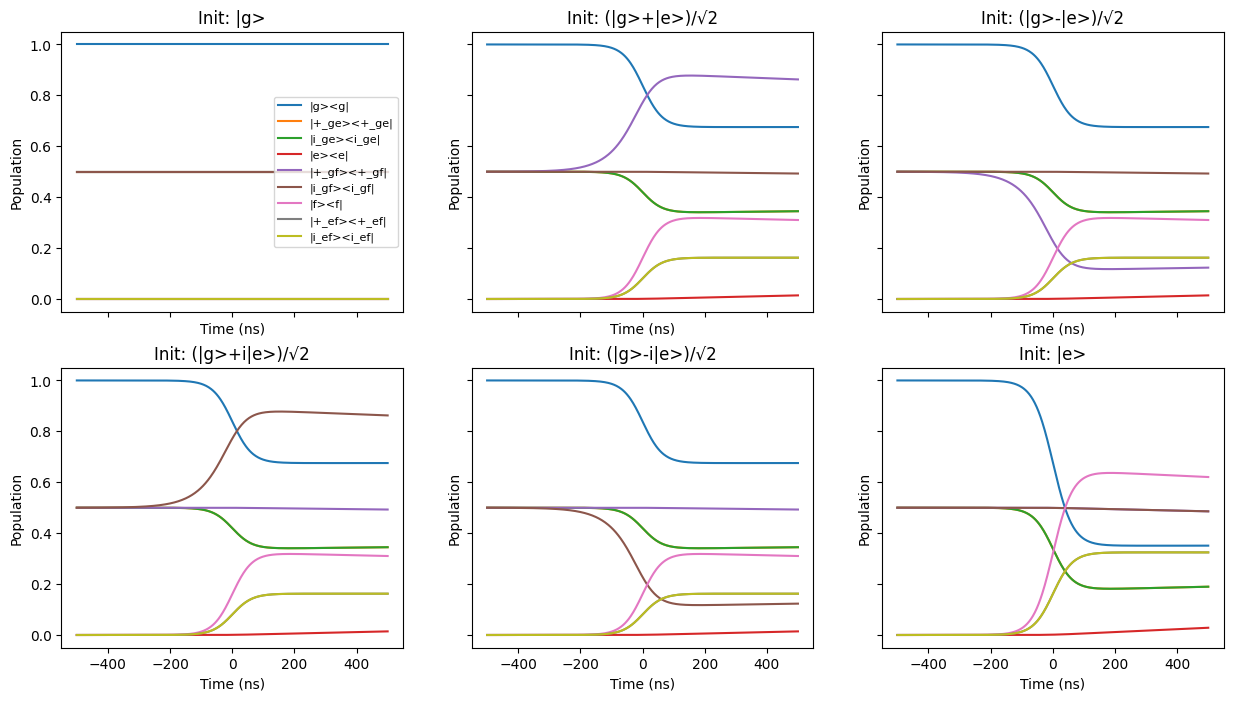

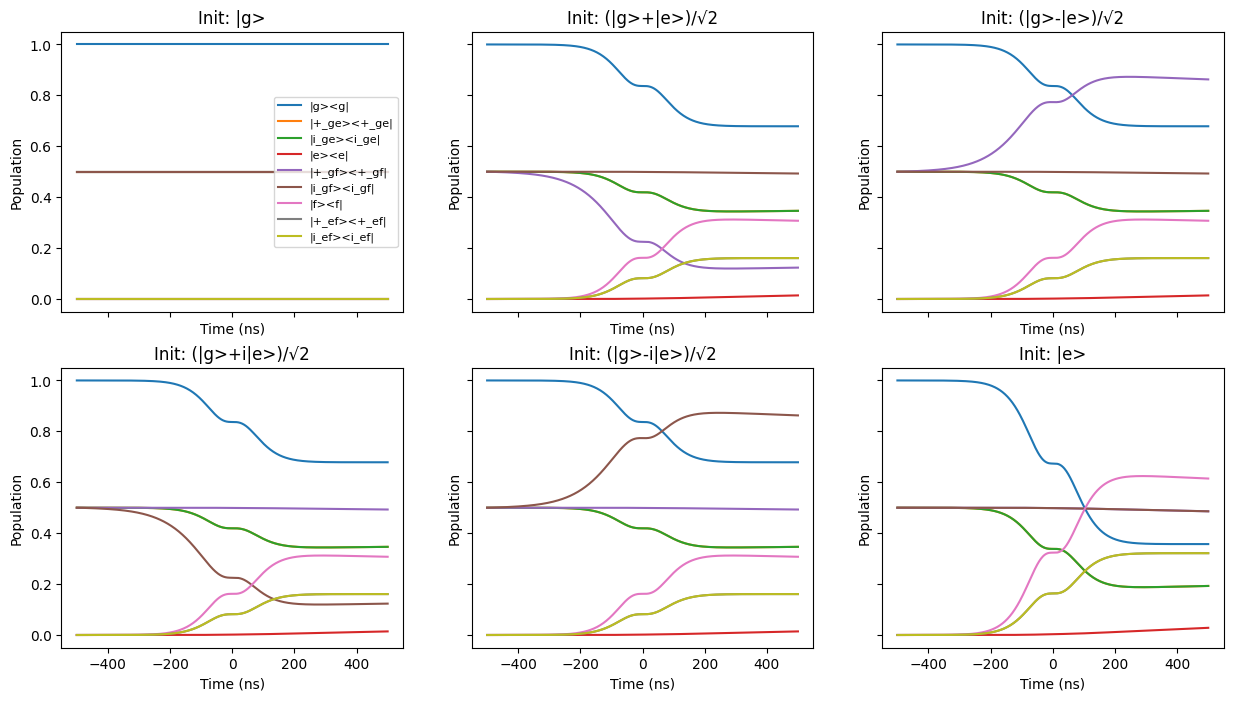

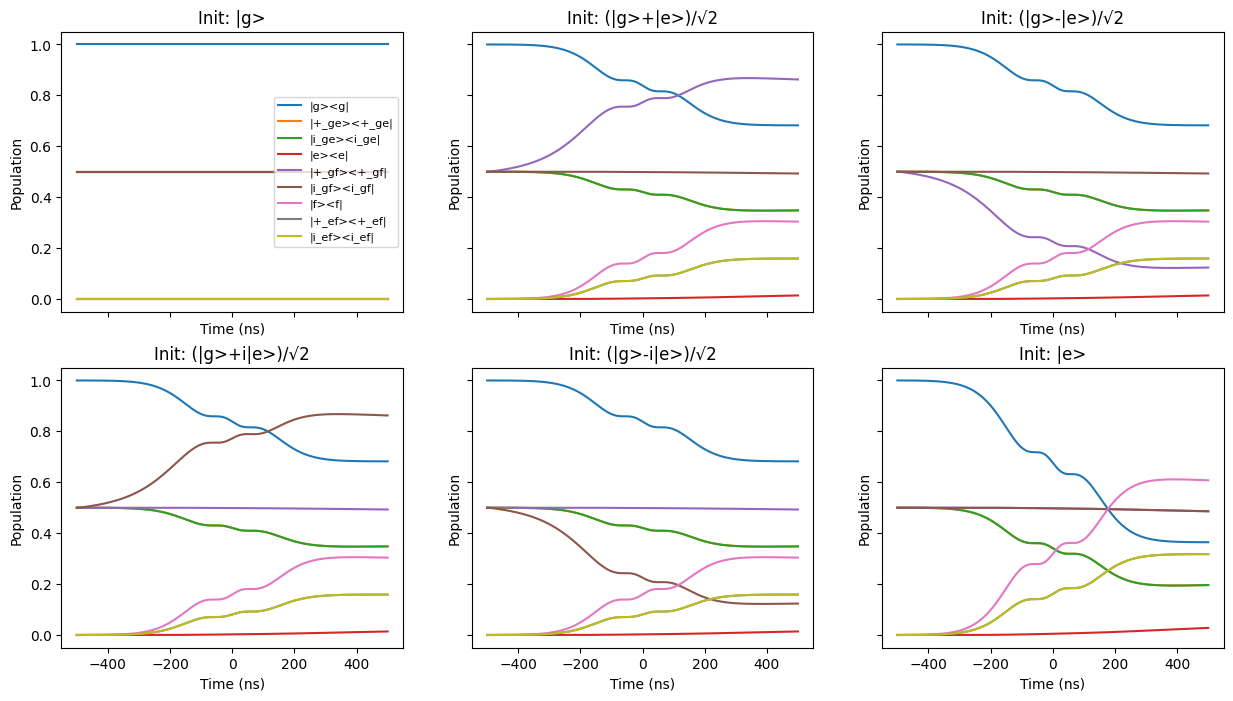

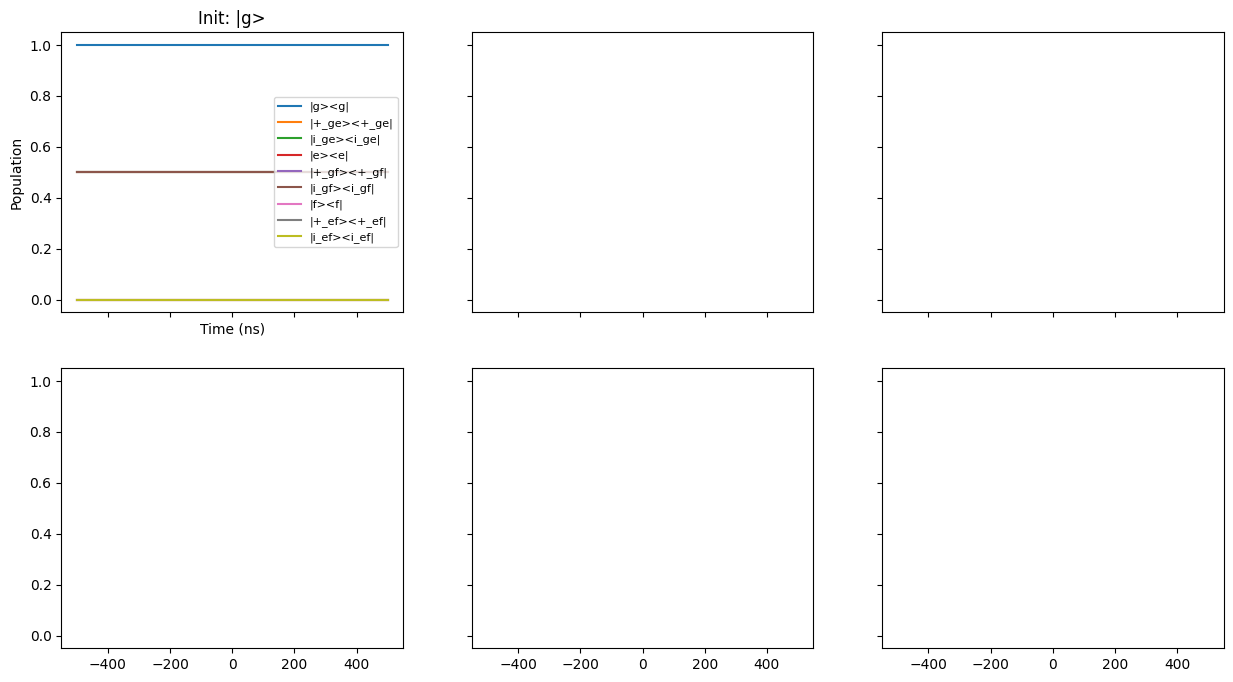

In [17]:
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

T = 500 
N = 501
tgrid = np.linspace(-T, T, N)
dt = tgrid[1] - tgrid[0]
kappa_ph = 2.5e-3 * 2 * np.pi * 2

_eps = 1e-14

gA_interps = []
gB_interps = []

for m in range(4):  
    f_vals = f(tgrid, m, kappa_ph)
    f_prime_vals = f_prime(tgrid, m, kappa_ph) 
    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, tgrid, initial=0)

    numerator_A = f_prime_vals + (kappa_A * f_vals / 2)
    denominator_A = np.sqrt(kappa_A * (1.0 - integral_vals) - f2_vals)
    gA_vals = numerator_A / denominator_A
    gA_interp = interp1d(tgrid, np.real(gA_vals), kind='cubic', fill_value='extrapolate')
    gA_interps.append(gA_interp)

    numerator_B = f_prime_vals + (kappa_B * f_vals / 2)
    denominator_B = np.sqrt(kappa_B * (1.0 - integral_vals) - f2_vals)
    gB_vals = numerator_B / denominator_B
    gB_interp = interp1d(tgrid, np.real(gB_vals[::-1]), kind='cubic', fill_value='extrapolate') 
    gB_interps.append(gB_interp)


def g_time_A(t, args):
    t_local = float(t) - float(args["center_A"])
    m = int(args["mode_num"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["gA_interps"][m](t_local))

def g_time_B(t, args):
    # t_local = float(t) - float(args["center_B"])
    t_local = float(t) - float(args["center_B"])
    m = int(args["mode_num"])
    return float(args["gB_interps"][m](t_local))

init_states = [
    ("|g>", g0_A),
    ("(|g>+|e>)/√2", (g0_A + f0_A).unit()),
    ("(|g>-|e>)/√2", (g0_A - f0_A).unit()),
    ("(|g>+i|e>)/√2", (g0_A + 1j*f0_A).unit()),
    ("(|g>-i|e>)/√2", (g0_A - 1j*f0_A).unit()),
    ("|e>", f0_A)
]


base_args = {
    "center_A": 0.0,
    "center_B": 0.0,
    "mode_num": 0, 
    "gA_interps": gA_interps,
    "gB_interps": gB_interps
}

H = [
    H_fogi_A + H_fogi_B + H_c,
    [H_d_A, g_time_A],
    [H_d_B, g_time_B],
]

mode_to_run = 0
args_run = base_args.copy()
args_run["mode_num"] = mode_to_run

results_all_m = []
for mode_num in range(1):
    m = mode_num
    print(f"%%%%%%%%%%%%%%%")
    print(f"mode {m}")
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
    axes = axes.flatten()
    results=[]
    for idx, (label, psi0) in enumerate(init_states):
        args_run = base_args.copy()
        args_run["mode_num"] = m
        result = qt.mesolve(
            H, psi0, tgrid, c_ops, e_ops=POVMs_full,
            args=args_run, options=options, progress_bar=True
        )
        results.append(result)
        ax = axes[idx]
        for i, l in enumerate(e_labels):
            ax.plot(tgrid, np.abs(result.expect[i]), label=l)
        ax.set_title(f"Init: {label}")
        ax.set_xlabel("Time (ns)")
        ax.set_ylabel("Population")
        if idx == 0:
            ax.legend(fontsize=8)
    results_all_m.append(results)

plt.tight_layout()
plt.show()

In [22]:
(g0_A + f0_A).unit()

Quantum object: dims=[[3, 2, 2, 3], [1, 1, 1, 1]], shape=(36, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.70710678]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]]

c:\Users\qipe\Documents\qutip_simulation\codes\state_tomography.py:149: RuntimeWarning: invalid value encountered in divide
  f_over_Prob = np.nan_to_num(mesured_prob/Prob, nan=0.0) # 頻度/確率の配列


6.283235817386569 4.9189206379174655
[[ 1.+0.j  0.+0.j -0.+0.j]
 [ 0.-0.j  0.-0.j -0.+0.j]
 [-0.+0.j -0.+0.j -0.-0.j]]
[[ 0.675+0.j  0.37 +0.j -0.   +0.j]
 [ 0.37 -0.j  0.31 -0.j -0.   +0.j]
 [ 0.   +0.j  0.   +0.j  0.014+0.j]]
[[ 0.675-0.j -0.37 -0.j -0.   +0.j]
 [-0.37 +0.j  0.31 +0.j -0.   -0.j]
 [ 0.   +0.j  0.   -0.j  0.014-0.j]]
[[ 0.675-0.j    0.   -0.37j  0.   +0.j  ]
 [ 0.   +0.37j  0.31 +0.j   -0.   +0.j  ]
 [-0.   +0.j    0.   +0.j    0.014-0.j  ]]
[[ 0.675+0.j   -0.   +0.37j -0.   +0.j  ]
 [-0.   -0.37j  0.31 -0.j    0.   +0.j  ]
 [ 0.   +0.j   -0.   +0.j    0.014-0.j  ]]
[[ 0.351+0.j  0.   -0.j  0.   +0.j]
 [-0.   -0.j  0.621-0.j -0.   +0.j]
 [-0.   +0.j  0.   +0.j  0.028-0.j]]
[1.      0.8626  0.8626  0.8626  0.8626  0.62057]


C:\Users\qipe\AppData\Local\Temp\ipykernel_15500\2108826216.py:92: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


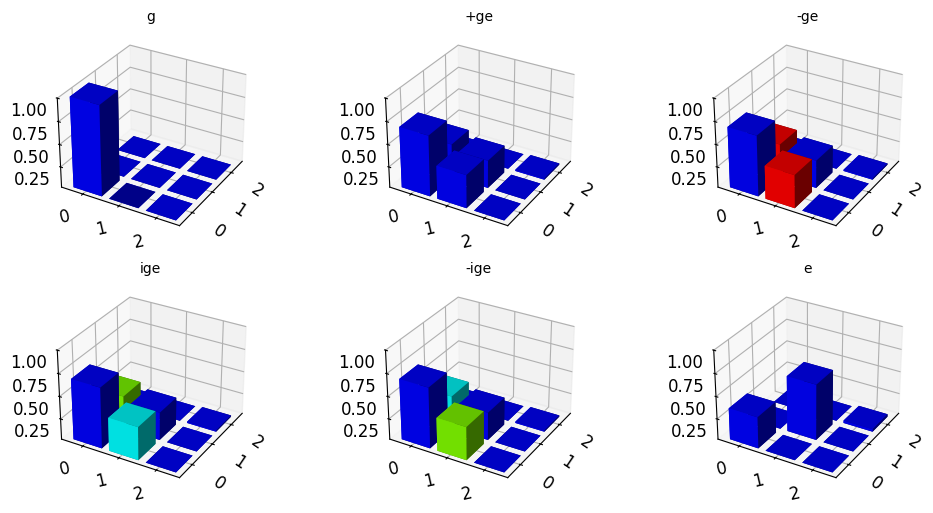

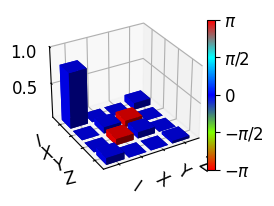

chi : [[ 7.74852121e-01+1.74702578e-15j  6.59330472e-16+2.73399953e-15j
  -1.59248971e-14+3.73305099e-15j  9.48578948e-02-1.86741295e-05j]
 [-1.10527771e-15-3.21636375e-14j  8.77496515e-02+6.56781738e-15j
  -8.77496515e-02-2.17150202e-15j  1.61138562e-14+2.56996437e-14j]
 [-1.91634804e-14+3.30089422e-15j -8.77496515e-02-1.25522393e-15j
   8.77496515e-02-3.14109142e-15j  4.19603723e-15+3.11369912e-15j]
 [ 9.48578948e-02+1.86741295e-05j  1.89083503e-14+2.52436221e-14j
  -3.58727260e-15-3.17106698e-14j  3.54320890e-02-5.15981639e-15j]]
Process fidelity : 0.77485
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
Process chi fidelity : 0.77485+0.00000j


c:\Users\qipe\Documents\qutip_simulation\codes\state_tomography.py:149: RuntimeWarning: invalid value encountered in divide
  f_over_Prob = np.nan_to_num(mesured_prob/Prob, nan=0.0) # 頻度/確率の配列


3.1413987486432893 3.1415926535571033
[[ 1.+0.j -0.+0.j  0.+0.j]
 [-0.+0.j  0.-0.j -0.-0.j]
 [-0.-0.j  0.+0.j  0.-0.j]]
[[ 0.679-0.j  0.37 -0.j  0.   +0.j]
 [ 0.37 +0.j  0.307+0.j  0.   -0.j]
 [-0.   +0.j -0.   -0.j  0.014-0.j]]
[[ 0.679+0.j -0.37 +0.j  0.   +0.j]
 [-0.37 -0.j  0.307-0.j -0.   +0.j]
 [-0.   +0.j  0.   +0.j  0.014+0.j]]
[[ 0.679+0.j   -0.   -0.37j  0.   +0.j  ]
 [-0.   +0.37j  0.307-0.j   -0.   +0.j  ]
 [-0.   +0.j    0.   +0.j    0.014+0.j  ]]
[[ 0.679-0.j    0.   +0.37j  0.   -0.j  ]
 [ 0.   -0.37j  0.307+0.j   -0.   -0.j  ]
 [-0.   -0.j    0.   -0.j    0.014-0.j  ]]
[[ 0.357+0.j -0.   +0.j  0.   -0.j]
 [ 0.   +0.j  0.615-0.j -0.   +0.j]
 [-0.   -0.j  0.   +0.j  0.028-0.j]]
[1.      0.86265 0.86265 0.86265 0.86265 0.61464]


C:\Users\qipe\AppData\Local\Temp\ipykernel_15500\2108826216.py:92: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


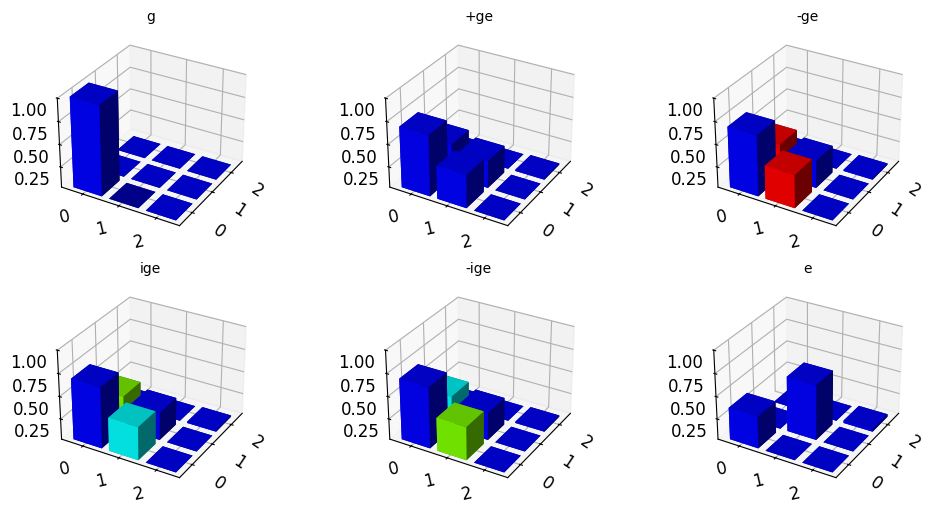

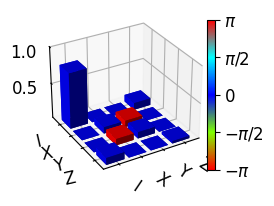

chi : [[ 7.73361933e-01-1.58847816e-15j -1.47142947e-15-1.91110803e-13j
   1.96593126e-13-3.06719836e-15j  9.63395119e-02+7.16869398e-05j]
 [ 1.32974339e-15+2.04533003e-13j  8.92893847e-02+8.64688471e-15j
  -8.92893847e-02-2.30521945e-15j -1.96694058e-13-9.77518962e-15j]
 [ 1.99017183e-13-3.16936262e-15j -8.92893847e-02-2.69429923e-15j
   8.92893847e-02-3.64736603e-15j -3.69401579e-15-1.91539061e-13j]
 [ 9.63395119e-02-7.16869398e-05j -1.98785049e-13-9.83955881e-15j
   3.60784087e-15+2.04017571e-13j  3.39590431e-02-3.19580788e-15j]]
Process fidelity : 0.77336
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
Process chi fidelity : 0.77336-0.00000j


c:\Users\qipe\Documents\qutip_simulation\codes\state_tomography.py:149: RuntimeWarning: invalid value encountered in divide
  f_over_Prob = np.nan_to_num(mesured_prob/Prob, nan=0.0) # 頻度/確率の配列


1.9010892642691611e-07 1.0471975229271677
[[1.+0.j 0.+0.j 0.-0.j]
 [0.-0.j 0.-0.j 0.-0.j]
 [0.-0.j 0.+0.j 0.-0.j]]
[[ 0.682+0.j  0.369+0.j -0.   -0.j]
 [ 0.369-0.j  0.304-0.j -0.   -0.j]
 [ 0.   -0.j  0.   -0.j  0.014+0.j]]
[[ 0.682-0.j -0.369-0.j  0.   -0.j]
 [-0.369+0.j  0.304+0.j  0.   +0.j]
 [-0.   -0.j -0.   +0.j  0.014-0.j]]
[[ 0.682-0.j     0.   -0.369j -0.   -0.j   ]
 [ 0.   +0.369j  0.304+0.j     0.   -0.j   ]
 [ 0.   -0.j    -0.   -0.j     0.014-0.j   ]]
[[ 0.682+0.j    -0.   +0.369j -0.   -0.j   ]
 [-0.   -0.369j  0.304-0.j    -0.   +0.j   ]
 [ 0.   -0.j     0.   +0.j     0.014-0.j   ]]
[[ 0.364+0.j -0.   -0.j -0.   -0.j]
 [ 0.   -0.j  0.608-0.j -0.   -0.j]
 [ 0.   -0.j  0.   -0.j  0.028-0.j]]
[1.      0.86247 0.86247 0.86247 0.86247 0.60768]


C:\Users\qipe\AppData\Local\Temp\ipykernel_15500\2108826216.py:92: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


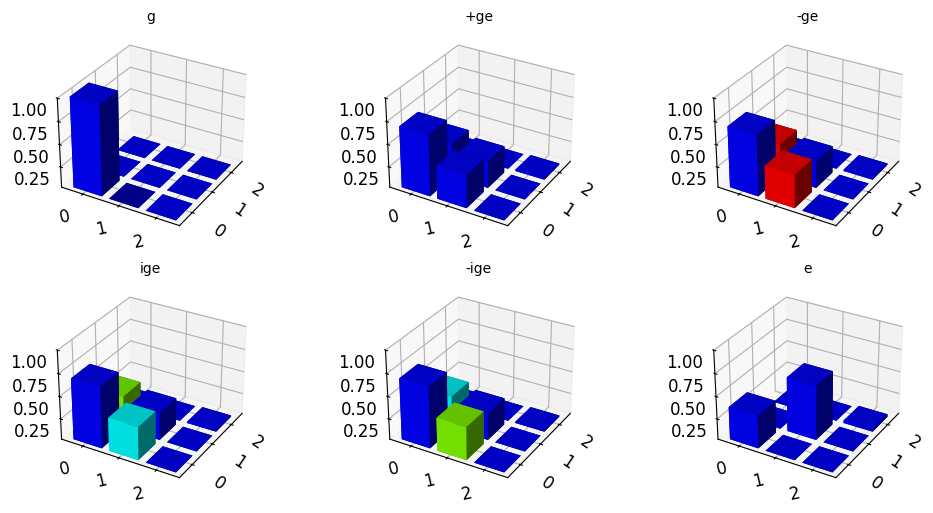

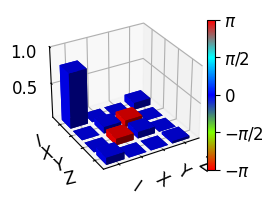

chi : [[ 7.71379735e-01+5.66464725e-16j -9.46378598e-15-1.21392132e-12j
   1.20275925e-12+1.51302582e-14j  9.80794137e-02-7.02374802e-08j]
 [-2.21282545e-14+1.19174268e-12j  9.10949630e-02-6.36996816e-16j
  -9.10949630e-02-2.13623463e-15j -1.20264922e-12+3.81932003e-14j]
 [ 1.20287101e-12-1.64575281e-14j -9.10949630e-02-1.82625615e-15j
   9.10949630e-02+4.59948760e-15j  2.19475996e-14-1.21352775e-12j]
 [ 9.80794137e-02+7.02374839e-08j -1.20309405e-12+6.49827418e-15j
   9.85409465e-15+1.19229279e-12j  3.24614375e-02-4.21915470e-15j]]
Process fidelity : 0.77138
<class 'numpy.ndarray'> int64 (4, 4)
<class 'numpy.ndarray'> complex128 (4, 4)
Process chi fidelity : 0.77138+0.00000j


In [23]:
for m in range(len(results_all_m)):
    name_dict = dict(
        data1 = dict(state="g",     data=results_all_m[m][0], ideal=np.outer(g_trit, g_trit.conj())), 
        data2 = dict(state="+ge",   data=results_all_m[m][1], ideal=np.outer(p_ge, p_ge.conj())), 
        data5 = dict(state="-ge",   data=results_all_m[m][2], ideal=np.outer(m_ge, m_ge.conj())), 
        data3 = dict(state="ige",   data=results_all_m[m][3], ideal=np.outer(i_ge, i_ge.conj())), 
        data6 = dict(state="-ige",  data=results_all_m[m][4], ideal=np.outer(mi_ge, mi_ge.conj())), 
        data4 = dict(state="e",     data=results_all_m[m][5], ideal=np.outer(e_trit, e_trit.conj())), 
    )
    if m==2:
        show_tomography_result_sim(name_dict, init_angles=(np.pi*3/4, np.pi/3))  
    else:
        show_tomography_result_sim(name_dict, init_angles=(np.pi, np.pi))

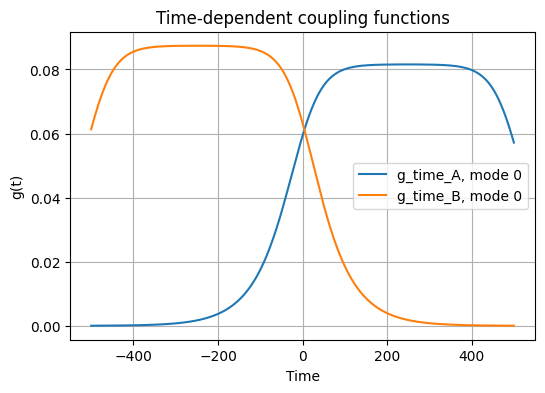

In [12]:
def g_time_A_vec(t_array, args):
    t_local = np.array(t_array) - args["center_A"]
    m = int(args["mode_num"])
    return np.array([float(args["gA_interps"][m](ti)) for ti in t_local])

def g_time_B_vec(t_array, args):
    t_local = (np.array(t_array) - args["center_B"])
    m = int(args["mode_num"])
    return np.array([float(args["gB_interps"][m](ti)) for ti in t_local])

mode_to_plot = 0
args_run = base_args.copy()
args_run["mode_num"] = mode_to_plot

plt.figure(figsize=(6,4))
plt.plot(tgrid, g_time_A_vec(tgrid, args_run), label=f"g_time_A, mode {mode_to_plot}")
plt.plot(tgrid, g_time_B_vec(tgrid, args_run), label=f"g_time_B, mode {mode_to_plot}")
plt.xlabel("Time")
plt.ylabel("g(t)")
plt.title("Time-dependent coupling functions")
plt.legend()
plt.grid(True)
plt.show()
